In [1]:
# Import Libraries

import gc
import sys
import tensorflow as tf
import tensorflow.keras as keras
import numpy as np
import matplotlib.pyplot as plt

import golois

print ("Python version", sys.version_info)
print ("Tensorflow version", tf.__version__)


Python version sys.version_info(major=3, minor=9, micro=21, releaselevel='final', serial=0)
Tensorflow version 2.15.0


In [2]:
# Configuration

planes = 31
moves = 361
N = 10000


input_data = np.random.randint(2, size=(N, 19, 19, planes))
input_data = input_data.astype ('float32')

policy = np.random.randint(moves, size=(N,))
policy = keras.utils.to_categorical (policy)

value = np.random.randint(2, size=(N,))
value = value.astype ('float32')

end = np.random.randint(2, size=(N, 19, 19, 2))
end = end.astype ('float32')

groups = np.zeros((N, 19, 19, 1))
groups = groups.astype ('float32')

In [3]:
# Get Validation Data

print ("getValidation", flush = True)
golois.getValidation (input_data, policy, value, end)

getValidation


r.shape = (10000, 19, 19, 31)
nbExamples = 10000
nbPositionsSGF = 102208897
nbPositionsSGF = 102208897
loading validation.data


In [4]:
#from tensorflow.keras.utils import plot_model
#from IPython.display import Image

from tensorflow import keras
from keras import regularizers
from keras.models import Model
from keras.layers import (
    Input, Dense, Conv2D, GlobalAveragePooling2D, Dropout, Flatten,
    Activation, BatchNormalization, Add, Reshape, DepthwiseConv2D, LeakyReLU,
    Multiply
)
from keras.utils import plot_model

def _se_block(input_tensor, filters, ratio=16, activation='relu'):
    se = GlobalAveragePooling2D()(input_tensor)
    se = Reshape((1, 1, filters))(se)
    se = Dense(filters // ratio, activation=activation, use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', use_bias=False)(se)
    return Multiply()([input_tensor, se])

def _conv_block(inputs, filters, kernel, activation='relu'):
    x = Conv2D(filters, kernel, padding='same', kernel_regularizer=regularizers.l2(0.0001), use_bias=False)(inputs)
    x = BatchNormalization(axis=1)(x)
    x = Activation(activation)(x)
    return x

def _bottleneck_block(inputs, filters, kernel, factor, se, activation='relu'):
    expanded_filters = filters * factor

    x = _conv_block(inputs, filters=expanded_filters, kernel=(1, 1), activation=activation)
    x = DepthwiseConv2D(kernel, padding='same', kernel_regularizer=regularizers.l2(0.0001), use_bias=False)(x)
    x = BatchNormalization(axis=1)(x)
    x = _conv_block(x, filters=filters, kernel=(1, 1), activation=activation)

    if se:
        x = _se_block(x, filters, 16, activation)

    x = Add()([x, inputs])
    x = Activation(activation)(x)
    return x

def GoMobileNetv2(input_shape, filters, factor, block_num, se, activation='relu', drop_out_rate=0.3):
    inputs = Input(shape=input_shape)
    x = _conv_block(inputs, filters, (1, 1), activation=activation)

    for i in range(block_num):
        x = _bottleneck_block(x, filters, (3, 3), factor, se, activation=activation)

    policy_head = _conv_block(x, filters=1, kernel=(1, 1), activation=activation)
    policy_head = Flatten()(policy_head)
    policy_head = Activation('softmax', name='policy')(policy_head)

    value_head = GlobalAveragePooling2D()(x)
    value_head = Dense(50, kernel_regularizer=regularizers.l2(0.0001))(value_head)
    value_head = Activation(activation)(value_head)
    value_head = Dropout(drop_out_rate)(value_head)
    value_head = Dense(1, activation='sigmoid', name='value',
                       kernel_regularizer=regularizers.l2(0.0001))(value_head)

    model = keras.Model(inputs=inputs, outputs=[policy_head, value_head])
    return model


In [25]:
import time
import pandas as pd
import gc
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import optimizers, backend as K

# Scheduler de learning rate
def get_learning_rate(epoch, epochs=100):
    if epoch < (epochs / 5) * 2.5:
        return 0.05
    elif epoch < (epochs / 5) * 3:
        return 0.005
    elif epoch < (epochs / 5) * 4:
        return 0.0005
    else:
        return 0.00005

def train_model(model, batch=32, policy_weight=1.0, value_weight=1.0, epochs=100):
    start_time = time.time()

    # Initial learning rate and optimizer
    lr = get_learning_rate(0, epochs)
    optimizer = optimizers.legacy.SGD(learning_rate=lr, momentum=0.9, nesterov=True)

    # Compilation
    model.compile(optimizer=optimizer,
                  loss={'policy': 'categorical_crossentropy', 'value': 'binary_crossentropy'},
                  loss_weights={'policy': policy_weight, 'value': value_weight},
                  metrics={'policy': 'categorical_accuracy', 'value': 'mse'})

    # Histories
    all_history = []
    val_loss_history = []

    for i in range(1, epochs + 1):
        lr = get_learning_rate(i, epochs)
        K.set_value(model.optimizer.learning_rate, lr)
        print('epoch', i, ', lr', lr)

        # Batch
        golois.getBatch(input_data, policy, value, end, groups, i * N)

        history = model.fit(input_data,
                            {'policy': policy, 'value': value},
                            epochs=1,
                            batch_size=batch,
                            verbose=1)

        # Stocker les métriques
        metrics = {key: val[0] for key, val in history.history.items()}
        metrics['epoch'] = i
        all_history.append(metrics)

        if i % 5 == 0:
            gc.collect()

        if i % 20 == 0:
            # Validation tous les 20 epochs
            golois.getValidation(input_data, policy, value, end)
            val = model.evaluate(input_data,
                                 [policy, value], verbose=0, batch_size=batch)
            print(f"Validation - policy: {val[1]:.4f}, value: {val[2]:.4f}")
            val_loss_history.append({'epoch': i, 'val_loss': val[0], 'val_policy_loss': val[1], 'val_value_loss': val[2]})

            model.save('mchettih.h5')

    total_time = time.time() - start_time
    return val, pd.DataFrame(all_history), pd.DataFrame(val_loss_history), total_time

In [18]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


def print_validation_results(model_results, epoch=100):
    """
    Affiche les résultats de validation pour une liste de modèles.

    Paramètres :
    - model_results : liste de tuples (model, val, label)
    - epoch : (optionnel) numéro d'epoch à afficher dans le titre
    """
    for model, val, label, time in model_results:
        metrics = dict(zip(model.metrics_names, val))
        title = f"📊 Validation Results for {label}"
        if epoch is not None:
            title += f" — Epoch {epoch}"
        print(f"\n{title}:")
        for name, value in metrics.items():
            print(f"  - {name:<30}: {value:.4f}")
        print(f"  - Time: {time:.4f}")
        
def plot_result(history_dfs, val_dfs, labels, epochs=None):
    assert len(history_dfs) == len(labels)

    # Titre
    info = []
    title = f"Epochs: {epochs}"

    # Grille personnalisée
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    gs = gridspec.GridSpec(2, 3)

    # --- Ligne 1 : 3 plots ---
    ax1 = fig.add_subplot(gs[0, 0])
    for df, val_df, label in zip(history_dfs, val_dfs, labels):
        ax1.plot(df['epoch'], df['loss'], label=f'{label} Train Loss')
        if not val_df.empty:
            ax1.plot(val_df['epoch'], val_df['val_loss'], 'o--', label=f'{label} Val Loss')
    ax1.set_title('Total Loss par Epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Total Loss')
    ax1.legend()

    ax2 = fig.add_subplot(gs[0, 1])
    for df, val_df, label in zip(history_dfs, val_dfs, labels):
        if 'policy_loss' in df.columns:
            ax2.plot(df['epoch'], df['policy_loss'], label=f'{label} Train Policy Loss')
        if not val_df.empty and 'val_policy_loss' in val_df.columns:
            ax2.plot(val_df['epoch'], val_df['val_policy_loss'], 'o--', label=f'{label} Val Policy Loss')
    ax2.set_title('Policy Loss par Epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Policy Loss')
    ax2.legend()

    ax3 = fig.add_subplot(gs[0, 2])
    for df, val_df, label in zip(history_dfs, val_dfs, labels):
        if 'value_loss' in df.columns:
            ax3.plot(df['epoch'], df['value_loss'], label=f'{label} Train Value Loss')
        if not val_df.empty and 'val_value_loss' in val_df.columns:
            ax3.plot(val_df['epoch'], val_df['val_value_loss'], 'o--', label=f'{label} Val Value Loss')
    ax3.set_title('Value Loss par Epoch')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Value Loss')
    ax3.legend()

    # --- Ligne 2 : 2 plots ---
    ax4 = fig.add_subplot(gs[1, 0])
    for df, label in zip(history_dfs, labels):
        if 'policy_categorical_accuracy' in df.columns:
            ax4.plot(df['epoch'], df['policy_categorical_accuracy'], label=f'{label} Train Policy Acc')
    ax4.set_title('Policy Accuracy par Epoch')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Categorical Accuracy')
    ax4.legend()

    ax5 = fig.add_subplot(gs[1, 1])
    for df, label in zip(history_dfs, labels):
        if 'value_mse' in df.columns:
            ax5.plot(df['epoch'], df['value_mse'], label=f'{label} Train Value MSE')
    ax5.set_title('Value MSE par Epoch')
    ax5.set_xlabel('Epoch')
    ax5.set_ylabel('MSE')
    ax5.legend()

    # Libérer la dernière case vide
    fig.delaxes(fig.add_subplot(gs[1, 2]))

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

epoch 1 , lr 0.05


r.shape = (10000, 19, 19, 31)
nbExamples = 10000


313/313 [==============================] - 18s 55ms/step - loss: 4.7139 - policy_loss: 3.9463 - value_loss: 0.6939 - policy_categorical_accuracy: 0.1897 - value_mse: 0.1209
epoch 2 , lr 0.05
  1/313 [..............................] - ETA: 19s - loss: 4.5418 - policy_loss: 3.7825 - value_loss: 0.6837 - policy_categorical_accuracy: 0.1562 - value_mse: 0.1271

r.shape = (10000, 19, 19, 31)
nbExamples = 10000


313/313 [==============================] - 17s 53ms/step - loss: 4.1917 - policy_loss: 3.4242 - value_loss: 0.6906 - policy_categorical_accuracy: 0.2606 - value_mse: 0.1215
epoch 3 , lr 0.05
  1/313 [..............................] - ETA: 19s - loss: 4.0221 - policy_loss: 3.2461 - value_loss: 0.6979 - policy_categorical_accuracy: 0.2500 - value_mse: 0.1294

...

313/313 [==============================] - 17s 55ms/step - loss: 3.7208 - policy_loss: 2.9498 - value_loss: 0.6859 - policy_categorical_accuracy: 0.3268 - value_mse: 0.1178
epoch 20 , lr 5e-05
  1/313 [..............................] - ETA: 18s - loss: 3.7396 - policy_loss: 2.9650 - value_loss: 0.6895 - policy_categorical_accuracy: 0.2500 - value_mse: 0.1193

r.shape = (10000, 19, 19, 31)
nbExamples = 10000


313/313 [==============================] - 17s 55ms/step - loss: 3.7245 - policy_loss: 2.9533 - value_loss: 0.6860 - policy_categorical_accuracy: 0.3196 - value_mse: 0.1204


r.shape = (10000, 19, 19, 31)
nbExamples = 10000


Validation - policy: 2.9265, value: 0.6854

📊 Validation Results for Mon Model — Epoch 100:
  - loss                          : 3.6971
  - policy_loss                   : 2.9265
  - value_loss                    : 0.6854
  - policy_categorical_accuracy   : 0.3234
  - value_mse                     : 0.1185
  - Time: 365.9566


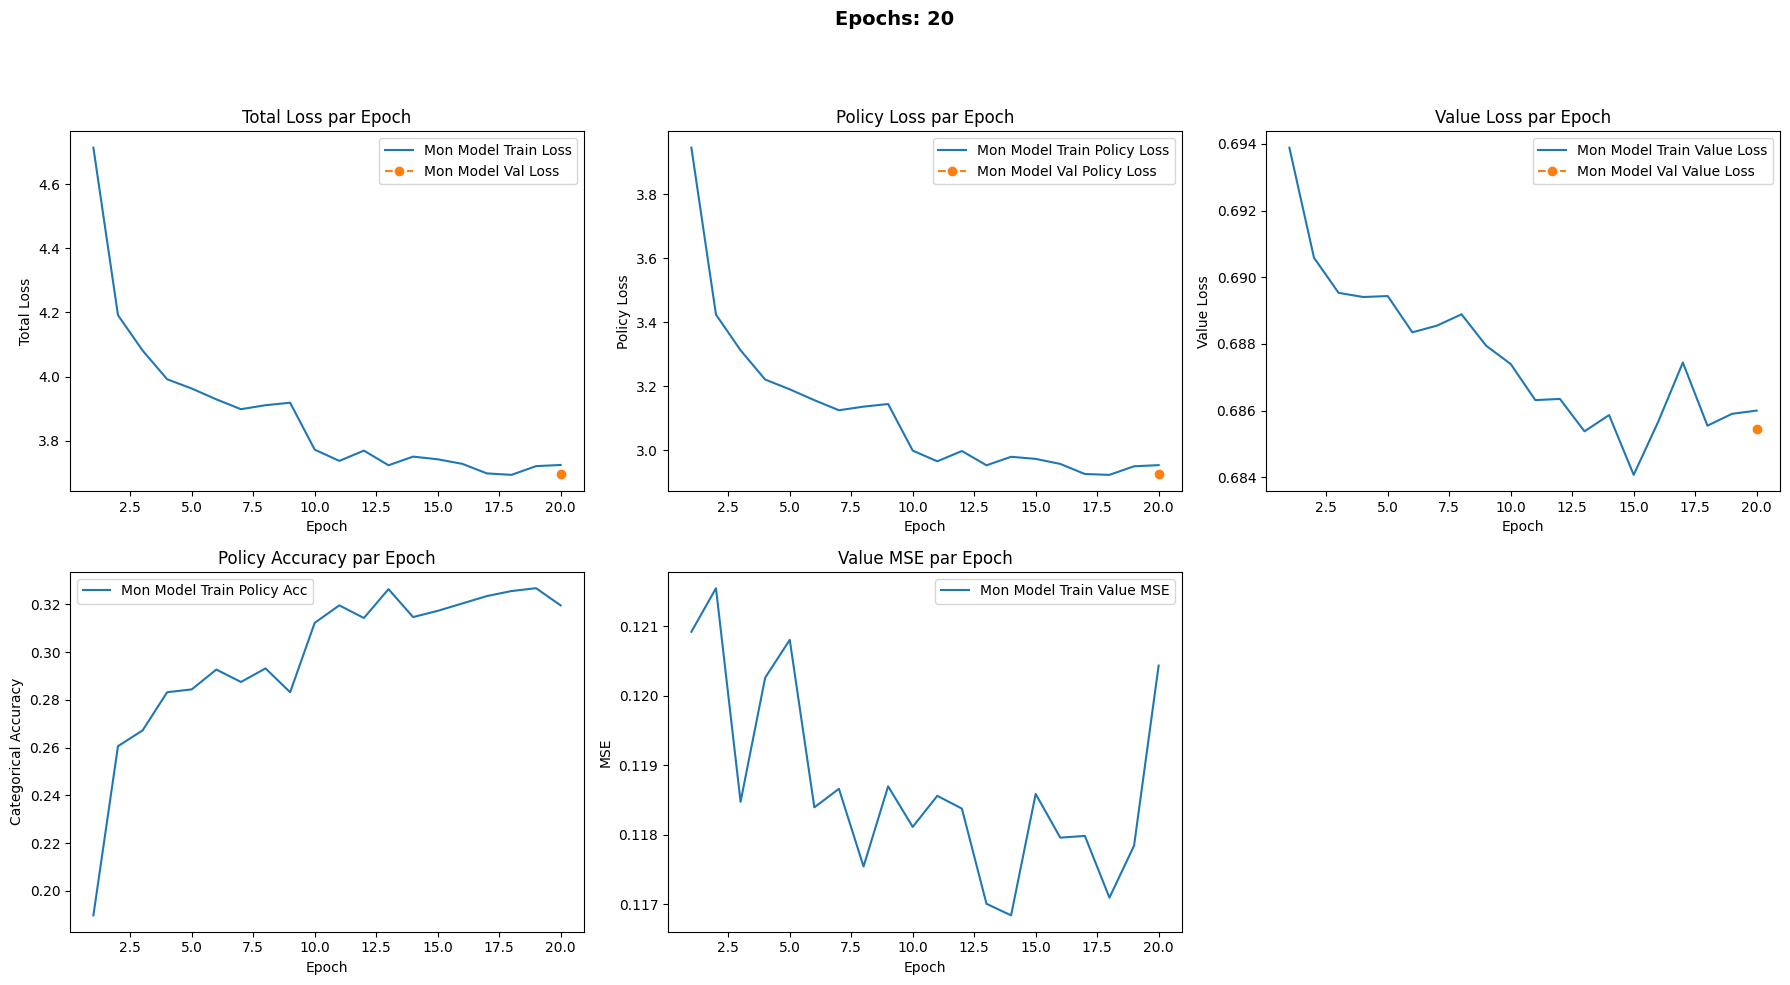

In [26]:
# Modèle 1 : GoMobileNetv2 (64,4,3) 
# - Nesterov  True 
# - SE True
# - Cosine Annealing
# - Batch size 32
# - Policy weight 1.0
# - Value weight 1.0

model = GoMobileNetv2((19,19,31), 64, 4, 3, True, activation='swish')

val, all_history, val_loss_history, total_time = train_model(
    model, 
    batch=32, 
    policy_weight=1.0, 
    value_weight=1.0, 
    epochs=20
)

# Affichage des résultats
results = [
    (model, val, "Mon Model", total_time)
]
print_validation_results(results)

# Affichage des courbes comparatives
plot_result(
    history_dfs=[all_history], 
    val_dfs=[val_loss_history], 
    labels=["Mon Model"], 
    epochs=20
)